# Mini-GPT Model from Scratch

In this notebook, we build a decoder-only transformer model (similar to GPT-2) from scratch. We will train it on a classic text dataset to generate new, original text.


## 1. Dataset

We will use *Alice's Adventures in Wonderland* as our training corpus.


In [1]:
import urllib.request

# Download the dataset
url = 'https://www.gutenberg.org/files/11/11-0.txt'
response = urllib.request.urlopen(url)
raw_text = response.read().decode('utf-8')

# Clean up some boilerplate Gutenberg text
start_idx = raw_text.find('ALICE\'S ADVENTURES IN WONDERLAND')
corpus = raw_text[start_idx:] if start_idx != -1 else raw_text

print(f"Corpus length: {len(corpus)} characters")
print(corpus[:500])


Corpus length: 144696 characters
*** START OF THE PROJECT GUTENBERG EBOOK 11 ***

[Illustration]




Alice’s Adventures in Wonderland

by Lewis Carroll

THE MILLENNIUM FULCRUM EDITION 3.0

Contents

 CHAPTER I.     Down the Rabbit-Hole
 CHAPTER II.    The Pool of Tears
 CHAPTER III.   A Caucus-Race and a Long Tale
 CHAPTER IV.    The Rabbit Sends in a Little Bill
 CHAPTER V.     Advice from a Caterpillar
 CHAPTER VI.    Pig and Pepper
 CHAPTER VII.   A Mad Tea-Party
 CHAPTER VIII.  The Queen’s Croquet-Ground
 CHAPTER IX.    The


## 2. Character Tokenizer

To process text, we map each unique character to an integer ID.


In [2]:
import torch

# Extract unique characters
vocabulary = sorted(list(set(corpus)))
vocab_size = len(vocabulary)
print(f"Vocabulary size: {vocab_size} unique characters")

# Build mapping dictionaries
char_to_id = {char: idx for idx, char in enumerate(vocabulary)}
id_to_char = {idx: char for idx, char in enumerate(vocabulary)}

# Encode and decode functions
def encode_text(text_string):
    return [char_to_id.get(c, 0) for c in text_string]

def decode_ids(id_list):
    return ''.join([id_to_char.get(i, '') for i in id_list])

encoded_data = torch.tensor(encode_text(corpus), dtype=torch.long)
print(f"Encoded tensor shape: {encoded_data.shape}")


Vocabulary size: 76 unique characters
Encoded tensor shape: torch.Size([144696])


## 3. Train / Validation Split

We divide the data into a training set and a validation set to evaluate generalization.


In [3]:
split_idx = int(0.9 * len(encoded_data))
train_split = encoded_data[:split_idx]
val_split = encoded_data[split_idx:]

print(f"Training tokens: {len(train_split)}")
print(f"Validation tokens: {len(val_split)}")


Training tokens: 130226
Validation tokens: 14470


## 4. Sequence Batches

We need to sample chunks of text (sequences) to feed into our model in batches.


In [4]:
sequence_length = 64
batch_size = 16

def sample_batch(dataset_type='train'):
    data = train_split if dataset_type == 'train' else val_split
    # Pick random starting indices
    start_indices = torch.randint(len(data) - sequence_length, (batch_size,))

    # Inputs (X) and Targets (Y) which are shifted by 1
    x_batch = torch.stack([data[i:i + sequence_length] for i in start_indices])
    y_batch = torch.stack([data[i + 1:i + sequence_length + 1] for i in start_indices])
    return x_batch, y_batch

x_sample, y_sample = sample_batch()
print(f"Batch Input Shape: {x_sample.shape}")
print(f"Batch Target Shape: {y_sample.shape}")


Batch Input Shape: torch.Size([16, 64])
Batch Target Shape: torch.Size([16, 64])


## 5. Bigram Baseline

Before building the full transformer, let's look at a simple Bigram model where predictions only depend on the immediately preceding character.


In [5]:
import torch.nn as nn
from torch.nn import functional as F

class SimpleBigramModel(nn.Module):
    def __init__(self, vocab_dim):
        super().__init__()
        self.embedding_table = nn.Embedding(vocab_dim, vocab_dim)

    def forward(self, x_inputs, y_targets=None):
        logits = self.embedding_table(x_inputs)
        loss_val = None
        if y_targets is not None:
            b, t, c = logits.shape
            logits_reshaped = logits.view(b * t, c)
            targets_reshaped = y_targets.view(b * t)
            loss_val = F.cross_entropy(logits_reshaped, targets_reshaped)
        return logits, loss_val

baseline_model = SimpleBigramModel(vocab_size)
logits_out, initial_loss = baseline_model(x_sample, y_sample)
print(f"Initial Bigram Loss: {initial_loss.item():.4f}")


Initial Bigram Loss: 4.8258


## 6. Self-Attention

Self-attention allows tokens to communicate with each other.


In [6]:
embed_dim = 128

class AttentionHead(nn.Module):
    def __init__(self, head_dim):
        super().__init__()
        self.q_proj = nn.Linear(embed_dim, head_dim, bias=False)
        self.k_proj = nn.Linear(embed_dim, head_dim, bias=False)
        self.v_proj = nn.Linear(embed_dim, head_dim, bias=False)

        # Causal mask will be applied in the next step
        self.register_buffer('causal_mask', torch.tril(torch.ones(sequence_length, sequence_length)))
        self.drop = nn.Dropout(0.1)

    def forward(self, hidden_states):
        b, t, c = hidden_states.shape
        queries = self.q_proj(hidden_states)
        keys = self.k_proj(hidden_states)

        # Attention scores
        attn_weights = (queries @ keys.transpose(-2, -1)) * (keys.shape[-1] ** -0.5)

        # 7. Causal Mask: Apply lower triangular mask
        attn_weights = attn_weights.masked_fill(self.causal_mask[:t, :t] == 0, float('-inf'))
        attn_weights = F.softmax(attn_weights, dim=-1)
        attn_weights = self.drop(attn_weights)

        values = self.v_proj(hidden_states)
        context = attn_weights @ values
        return context


## 7. Causal Mask

*(Implemented within the `AttentionHead` above to prevent looking into the future)*


## 8. Multi-Head Attention

Running multiple attention heads in parallel allows the model to capture different types of relationships simultaneously.


In [7]:
class MultiHeadAttentionGroup(nn.Module):
    def __init__(self, num_heads, head_dim):
        super().__init__()
        self.heads = nn.ModuleList([AttentionHead(head_dim) for _ in range(num_heads)])
        self.output_proj = nn.Linear(num_heads * head_dim, embed_dim)
        self.drop = nn.Dropout(0.1)

    def forward(self, hidden_states):
        concat_heads = torch.cat([head(hidden_states) for head in self.heads], dim=-1)
        return self.drop(self.output_proj(concat_heads))


## 9. Feed Forward + GELU

We add a feed-forward neural network to process the attention outputs. We use **GELU**, which is the activation function actually used in GPT-2.


In [8]:
class PositionWiseFeedForward(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, 4 * embed_dim),
            nn.GELU(), # GPT-2 uses GELU instead of ReLU
            nn.Linear(4 * embed_dim, embed_dim),
            nn.Dropout(0.1)
        )

    def forward(self, hidden_states):
        return self.net(hidden_states)


## 10. LayerNorm + Residual

We combine attention and feed-forward layers using residual connections and layer normalization for stable training.


In [9]:
class TransformerLayer(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        head_dim = embed_dim // num_heads
        self.attention = MultiHeadAttentionGroup(num_heads, head_dim)
        self.feed_forward = PositionWiseFeedForward(embed_dim)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, hidden_states):
        # Pre-norm formulation (used in GPT-2)
        hidden_states = hidden_states + self.attention(self.norm1(hidden_states))
        hidden_states = hidden_states + self.feed_forward(self.norm2(hidden_states))
        return hidden_states


## 11. MiniGPT Decoder

Bringing it all together into our final MiniGPT model.


In [10]:
class MiniGPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embeddings = nn.Embedding(vocab_size, embed_dim)
        self.position_embeddings = nn.Embedding(sequence_length, embed_dim)

        # Stack of transformer layers
        self.layers = nn.Sequential(
            TransformerLayer(embed_dim, num_heads=4),
            TransformerLayer(embed_dim, num_heads=4),
            TransformerLayer(embed_dim, num_heads=4),
            TransformerLayer(embed_dim, num_heads=4)
        )
        self.final_norm = nn.LayerNorm(embed_dim)
        self.lm_head = nn.Linear(embed_dim, vocab_size)

    def forward(self, input_ids, target_ids=None):
        b, t = input_ids.shape

        tok_emb = self.token_embeddings(input_ids)
        pos_emb = self.position_embeddings(torch.arange(t, device=input_ids.device))

        x = tok_emb + pos_emb
        x = self.layers(x)
        x = self.final_norm(x)
        logits = self.lm_head(x)

        loss = None
        if target_ids is not None:
            logits_flat = logits.view(-1, logits.size(-1))
            targets_flat = target_ids.view(-1)
            loss = F.cross_entropy(logits_flat, targets_flat)

        return logits, loss

    def generate_text(self, starting_ids, max_new_tokens):
        generated_ids = starting_ids
        for _ in range(max_new_tokens):
            # Crop context to max sequence length
            context = generated_ids[:, -sequence_length:]
            logits, _ = self(context)
            next_token_logits = logits[:, -1, :]
            probabilities = F.softmax(next_token_logits, dim=-1)
            next_token = torch.multinomial(probabilities, num_samples=1)
            generated_ids = torch.cat((generated_ids, next_token), dim=1)
        return generated_ids

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = MiniGPT().to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters())/1e6:.2f} M")


Model parameters: 0.82 M


## 12. Training

We train the model and track the loss to visualize its learning progress.


In [11]:
import matplotlib.pyplot as plt

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
training_steps = 3000
eval_interval = 250

train_losses_history = []
val_losses_history = []
step_history = []

@torch.no_grad()
def evaluate_loss():
    model.eval()
    results = {}
    for split in ['train', 'val']:
        losses = torch.zeros(50)
        for k in range(50):
            x_batch, y_batch = sample_batch(split)
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            _, loss = model(x_batch, y_batch)
            losses[k] = loss.item()
        results[split] = losses.mean().item()
    model.train()
    return results

for step in range(training_steps):
    if step % eval_interval == 0 or step == training_steps - 1:
        metrics = evaluate_loss()
        print(f"Step {step}: Train Loss = {metrics['train']:.4f} | Val Loss = {metrics['val']:.4f}")
        train_losses_history.append(metrics['train'])
        val_losses_history.append(metrics['val'])
        step_history.append(step)

    x_batch, y_batch = sample_batch('train')
    x_batch, y_batch = x_batch.to(device), y_batch.to(device)

    logits, loss = model(x_batch, y_batch)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()


Step 0: Train Loss = 4.5291 | Val Loss = 4.5313
Step 250: Train Loss = 2.2678 | Val Loss = 2.2823
Step 500: Train Loss = 1.8971 | Val Loss = 1.9219
Step 750: Train Loss = 1.6793 | Val Loss = 1.7601
Step 1000: Train Loss = 1.5695 | Val Loss = 1.6573
Step 1250: Train Loss = 1.4897 | Val Loss = 1.6188
Step 1500: Train Loss = 1.4287 | Val Loss = 1.5627
Step 1750: Train Loss = 1.3836 | Val Loss = 1.5348
Step 2000: Train Loss = 1.3272 | Val Loss = 1.5143
Step 2250: Train Loss = 1.2879 | Val Loss = 1.4805
Step 2500: Train Loss = 1.2485 | Val Loss = 1.5037
Step 2750: Train Loss = 1.2296 | Val Loss = 1.4643
Step 2999: Train Loss = 1.1919 | Val Loss = 1.4511


## 13. Loss Graph

Visualizing the training and validation loss over time.


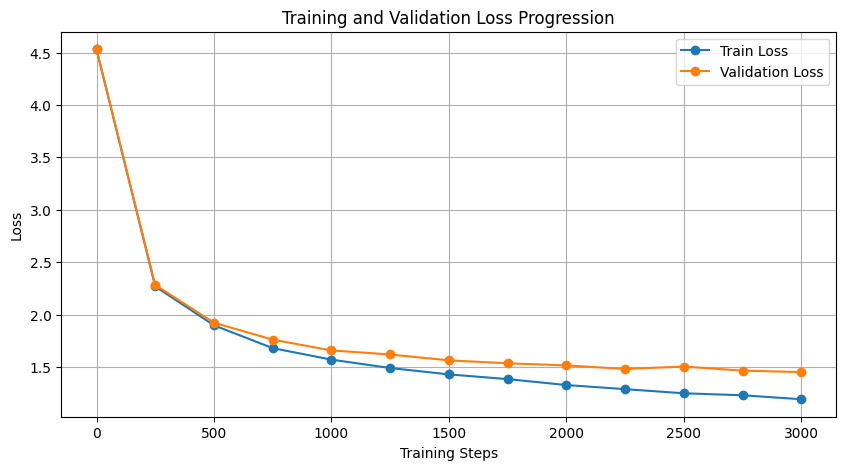

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(step_history, train_losses_history, label='Train Loss', marker='o')
plt.plot(step_history, val_losses_history, label='Validation Loss', marker='o')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Progression')
plt.legend()
plt.grid(True)
plt.show()


## 14. Text Generation

Let's see what our model has learned to generate!


In [13]:
model.eval()
start_context = torch.zeros((1, 1), dtype=torch.long, device=device)
generated_tokens = model.generate_text(start_context, max_new_tokens=500)
generated_text = decode_ids(generated_tokens[0].tolist())
print("\n--- Generated Text ---\n")
print(generated_text)



--- Generated Text ---


Queen in the woood snow,” Alice replied in riddly, and, “look, that’s a turn and growdle, thing how
more things!” And she couldn’t passily: “thunk Mary fire asleep such a neck
or of a, yy the pointo her; “St’s happen it tea long—” she findst dish), in a
slame of might, and very comclose. She got up by the first into Alice:
“she’s was have one of one the bettee goldeners on mad bro—oh, you’re body for, you knowlallt!” once said the
King, who has he said has to her puzzleed its voice.

“What, to b


## 15. Checkpoint

Finally, we save our model weights so we don't have to train from scratch next time.


In [14]:
import os

checkpoint_dir = 'checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

checkpoint_path = os.path.join(checkpoint_dir, 'minigpt_alice.pth')
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'vocab_size': vocab_size,
    'embed_dim': embed_dim
}, checkpoint_path)

print(f"Model successfully saved to {checkpoint_path}")


Model successfully saved to checkpoints/minigpt_alice.pth
